# linear regressions for non linear dataset

In [59]:
import numpy as np
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt

# 1 Dataset

In [60]:
x, y = make_regression(n_samples=100, n_features=1, noise = 10)
y = y + abs(y/2)

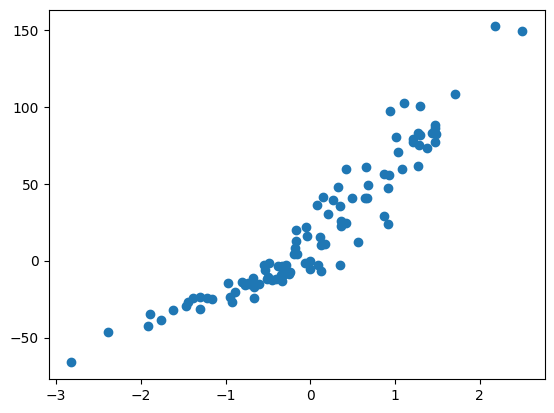

In [61]:
plt.scatter(x,y)

In [62]:
print(x.shape)
print(y.shape)

(100, 1)
(100,)


In [63]:
y = y.reshape(y.shape[0],1)
print(y.shape)

(100, 1)


In [64]:
# matrix X et biais
X = np.hstack((x, np.ones(x.shape)))
X = np.hstack((x**2, X))
X.shape

(100, 3)

In [65]:
X

array([[ 3.70182458e-01, -6.08426214e-01,  1.00000000e+00],
       [ 3.09446777e-02,  1.75910994e-01,  1.00000000e+00],
       [ 2.40893606e-01, -4.90809134e-01,  1.00000000e+00],
       [ 4.37229637e-01, -6.61233421e-01,  1.00000000e+00],
       [ 1.21790039e-01, -3.48984296e-01,  1.00000000e+00],
       [ 2.09599764e+00, -1.44775607e+00,  1.00000000e+00],
       [ 1.61139891e+00,  1.26940888e+00,  1.00000000e+00],
       [ 1.89660658e+00,  1.37717340e+00,  1.00000000e+00],
       [ 1.46779052e+00,  1.21152405e+00,  1.00000000e+00],
       [ 1.70790472e+00, -1.30686829e+00,  1.00000000e+00],
       [ 2.16219000e+00,  1.47043871e+00,  1.00000000e+00],
       [ 1.77510727e-01,  4.21320219e-01,  1.00000000e+00],
       [ 4.28343790e-01,  6.54479786e-01,  1.00000000e+00],
       [ 4.66398409e-01,  6.82933678e-01,  1.00000000e+00],
       [ 4.39364432e-01, -6.62845708e-01,  1.00000000e+00],
       [ 5.73042929e+00, -2.39383151e+00,  1.00000000e+00],
       [ 5.84893271e-02, -2.41845668e-01

In [66]:
theta = np.random.randn(3,1)
theta

array([[-0.31560578],
       [-0.2351554 ],
       [ 0.92994297]])

# 2 Modèle

In [67]:
def model(X, theta):
    return X.dot(theta)

In [68]:
model(X, theta)

array([[ 0.95618595],
       [ 0.87881023],
       [ 0.96933197],
       [ 0.94744337],
       [ 0.97357087],
       [ 0.60888164],
       [ 0.12286781],
       [ 0.00751321],
       [ 0.18180337],
       [ 0.69823549],
       [-0.0982383 ],
       [ 0.77484383],
       [ 0.64085074],
       [ 0.62214939],
       [ 0.94714876],
       [-0.31569126],
       [ 0.96835471],
       [ 0.73666121],
       [ 0.96381645],
       [ 0.70168738],
       [ 0.88880918],
       [-1.63432933],
       [ 0.30758868],
       [ 0.97337677],
       [ 0.88967059],
       [ 0.93083532],
       [ 0.96065056],
       [-0.10056452],
       [-1.07563924],
       [ 0.09252003],
       [ 0.78015885],
       [ 0.64668844],
       [ 0.48497135],
       [ 0.44476062],
       [ 0.65226817],
       [ 0.84305087],
       [ 0.92415532],
       [ 0.94431924],
       [ 0.24618685],
       [-0.06160854],
       [ 0.9716817 ],
       [ 0.74475174],
       [ 0.94134993],
       [ 0.9626261 ],
       [ 0.80853712],
       [ 0

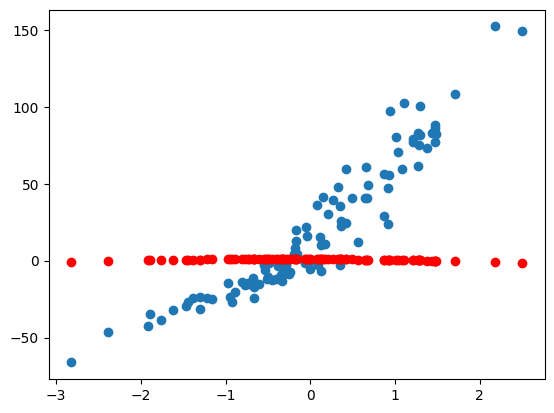

In [69]:
plt.scatter(x, y)
plt.scatter(x, model(X, theta), color = "red")

# Cost Functions

In [70]:
def cost_function(X, y, theta):
    m = len(y)
    return 1/(2*m) * np.sum((model(X, theta) - y) ** 2)

In [71]:
cost_function(X, y, theta)

np.float64(1187.390664193719)

# Gradient & Gradient Descent

In [72]:
def grad(X, y, theta):
    m = len(y)
    return 1/m * X.T.dot(model(X, theta) - y)

In [73]:
def GradientDescent(X, y, theta, learning_rate, n_iteration):
    cost_history = np.zeros(n_iteration)
    for i in range(0, n_iteration):
        theta -= learning_rate * grad(X, y, theta)
        cost_history[i] = cost_function(X, y, theta)
    return theta, cost_history


# Machine Learning !!!

In [74]:
theta_final, cost_history = GradientDescent(X, y, theta, learning_rate=0.01, n_iteration=1000)

In [75]:
theta_final

array([[ 7.09905033],
       [42.32319598],
       [11.86301219]])

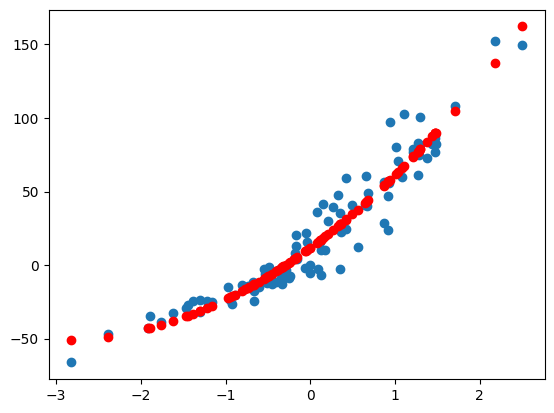

In [76]:
predictions = model(X, theta_final)
plt.scatter(x,y)
plt.scatter(x, predictions, color = "red")

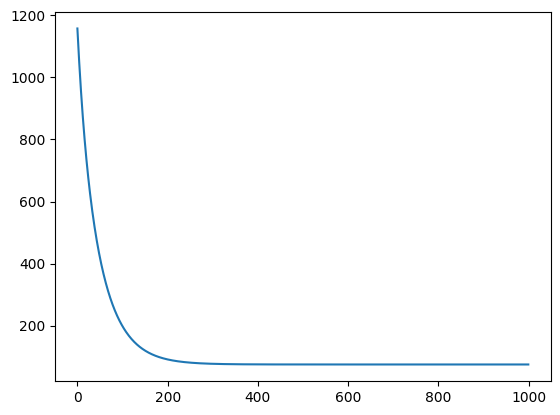

In [77]:
plt.plot(range(1000), cost_history)

# Coefficient de détermination R^2

In [78]:
def coef_determination(y, pred):
    u = ((y - pred) ** 2).sum()
    v = ((y - y.mean()) ** 2).sum()
    R_carre = 1 - ( u / v )
    return R_carre

In [79]:
coef_determination(y, predictions)

np.float64(0.9244107988766354)